# Phase 5 — Which graph should GraphSAGE use?

## 1 · The research question

**Given a dataset and a task, should GraphSAGE run on the original graph, or on a role-based virtual graph — `psi`, `degree`, `centrality`, or `hybrid`?**

- The **graph is the only thing that changes**: encoder, features, K = 10 and seeds 42/43/44 are the locked configuration.
- Each dataset × task case gets one of three answers — **keep original**, **tie**, or **augment** — decided against the 3-seed noise, not on point estimates.
- Then: can the answer be *predicted* from the dataset's own properties?
- n is 4–5 datasets per task → a conjecture offered to the community, not a significance test.

## 2 · What data already exists

**Nothing is trained or retrained here.** Every number is read from files the study already produced:

| read from | what it gives |
|---|---|
| `results/scoreboard.csv` | the locked GraphSAGE scores — 5 graph variants × 10 dataset × task cells × 3 seeds |
| `input/*.edgelist` (via `graph_io`) | the original graphs → size, degree, clustering, components |
| `labels/*.labels` | node labels → homophily (`ogbl_ddi` ships none) |
| `output/feature_cache/*.npz` | the raw, pre-z-norm values GraphSAGE was actually fed |

Metrics differ by protocol — weighted F1 / AUC for the core four, official Accuracy / Hits@20 for the OGB pair — so every comparison stays **inside** one dataset × task cell, and only the *ranking* of gaps is compared across cells (hence Spearman everywhere).

Heavy lifting lives in `characterize.py`; this notebook orchestrates and plots.

In [1]:
"""Setup: repo root, config, the characterization functions. Heavy lifting: characterize.py."""
import os, sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)                     # run everything from the repo root
sys.path[:0] = [str(Path.cwd()), str(Path.cwd() / "scripts")]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import benchmark_config as cfg
from characterize import (STUDY, PREDICTORS, graph_properties, feature_properties,
                          frozen_inputs, gaps, feature_scores, correlate, rule)

DATASETS = list(STUDY)                              # all six study datasets
ORDER = ["original", "psi", "degree", "centrality", "hybrid"]      # control first, then the four augmented graphs
cfg.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25})

# Saves a figure to results/figures/ and shows it.
def show(fig, name):
    """Save under results/figures/ and display."""
    fig.tight_layout()
    fig.savefig(cfg.FIGURES_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()

/home/m-adam/miniconda/envs/i2v/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
"""Read everything the study already produced - same six calls as `characterize.py --step all`."""
props = pd.DataFrame([graph_properties(ds) for ds in DATASETS])                  # what each dataset is like
dists = pd.DataFrame([r for ds in DATASETS for r in feature_properties(ds)])     # raw values fed to GraphSAGE
scores = frozen_inputs(DATASETS)                                                 # locked GraphSAGE scores, K=10, 3 seeds
gap = gaps(scores)                                                               # original vs best augmented, per cell
ablation = feature_scores(dists)                                                 # ablation D + each feature's raw spread
corr = correlate(props, gap, ablation)                                           # Spearman, both scopes

print(f"{len(props)} datasets | {len(scores)} scores | {len(gap)} dataset x task cells "
      f"| {len(ablation)} ablation rows | {len(dists)} feature distributions")

6 datasets | 50 scores | 10 dataset x task cells | 74 ablation rows | 24 feature distributions


## 3 · Which graph wins?

All five variants side by side, one row per dataset × task.

- `winner` = the highest 3-seed mean of the five.
- `verdict` compares the **best augmented** graph against the **original** inside a 1σ band on the pooled 3-seed noise — so "keep original" is a measured call, not a reading of point estimates.
- In the heatmap, colour = score ÷ the original graph's score (white = ties it); the printed numbers are the raw means.

In [3]:
"""Every variant's score, the winner, and the verdict - one row per dataset x task cell."""
piv = scores.pivot_table(index=["task", "dataset"], columns="graph_variant", values="mean")
piv = piv.reindex(columns=ORDER).sort_index()

table = piv.join(gap.set_index(["task", "dataset"])[["metric", "best_variant", "gap_abs", "gap_sigma", "verdict"]])
table.insert(len(ORDER), "winner", piv.idxmax(axis=1))
table.round(4)

original     psi  degree  \
task                               dataset                                    
link prediction (AUC)              citeseer_linqs    0.6218  0.5057  0.5415   
                                   cora              0.6130  0.5150  0.5391   
                                   enzymes           0.7000  0.6236  0.5484   
                                   proteins          0.6720  0.5578  0.5507   
link prediction (OGB official)     ogbl_ddi          0.0173  0.0423  0.0331   
node classification (OGB official) ogbn_arxiv        0.3918  0.2466  0.2416   
node classification (weighted F1)  citeseer_linqs    0.3298  0.2327  0.2291   
                                   cora              0.4266  0.2351  0.2351   
                                   enzymes           0.5591  0.5480  0.5474   
                                   proteins          0.5797  0.5588  0.5588   

                                                   centrality  hybrid  \
task                               dataset                              
link prediction (AUC)              citeseer_linqs      0.5437  0.5166   
                                   cora                0.5659  0.5463   
                                   enzymes             0.6563  0.6322   
                                   proteins            0.5834  0.5623   
link prediction (OGB official)     ogbl_ddi            0.0519  0.0344   
node classification (OGB official) ogbn_arxiv          0.2658  0.3618   
node classification (weighted F1)  citeseer_linqs      0.2818  0.2698   
                                   cora                0.2942  0.2918   
                                   enzymes             0.5372  0.5546   
                                   proteins            0.5543  0.5646   

                                                       winner        metric  \
task                               dataset                                    
link prediction (AUC)              citeseer_linqs    original           auc   
                                   cora              original           auc   
                                   enzymes           original           auc   
                                   proteins          original           auc   
link prediction (OGB official)     ogbl_ddi        centrality  test_hits@20   
node classification (OGB official) ogbn_arxiv        original      test_acc   
node classification (weighted F1)  citeseer_linqs    original   weighted_f1   
                                   cora              original   weighted_f1   
                                   enzymes           original   weighted_f1   
                                   proteins          original   weighted_f1   

                                                  best_variant  gap_abs  \
task                               dataset                                
link prediction (AUC)              citeseer_linqs   centrality  -0.0781   
                                   cora             centrality  -0.0471   
                                   enzymes          centrality  -0.0437   
                                   proteins         centrality  -0.0886   
link prediction (OGB official)     ogbl_ddi         centrality   0.0346   
node classification (OGB official) ogbn_arxiv           hybrid  -0.0300   
node classification (weighted F1)  citeseer_linqs   centrality  -0.0480   
                                   cora             centrality  -0.1324   
                                   enzymes              hybrid  -0.0045   
                                   proteins             hybrid  -0.0151   

                                                   gap_sigma        verdict  
task                               dataset                                   
link prediction (AUC)              citeseer_linqs      -3.64  keep original  
                                   cora               -11.54  keep original  
                                   enzymes             -6.09  k

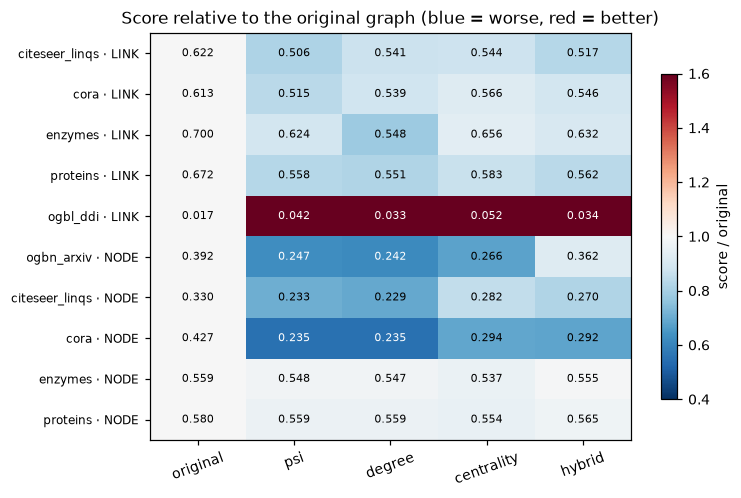

In [4]:
"""The same table as a picture: how far each variant lands from the original graph."""
ratio = piv.div(piv["original"], axis=0)

fig, ax = plt.subplots(figsize=(7, 4.6))
im = ax.imshow(ratio.values, cmap="RdBu_r", vmin=0.4, vmax=1.6, aspect="auto")
ax.grid(False)
ax.set_xticks(range(len(ORDER)), ORDER, rotation=20)
ax.set_yticks(range(len(piv)), [f"{d} · {t.split(' (')[0][:4].upper()}" for t, d in piv.index], fontsize=8)
for i in range(piv.shape[0]):                                   # annotate with the real score, colour carries the ratio
    for j in range(piv.shape[1]):
        dark = abs(ratio.values[i, j] - 1) > 0.35               # keep the label readable on saturated cells
        ax.text(j, i, f"{piv.values[i, j]:.3f}", ha="center", va="center", fontsize=7.5,
                color="white" if dark else "black")
ax.set_title("Score relative to the original graph (blue = worse, red = better)")
fig.colorbar(im, ax=ax, label="score / original", shrink=0.8)
show(fig, "fig1_variant_vs_original")

## 4 · What is each dataset like?

Five properties do the explaining below. The full 30-column measurement is `results/dataset_characterization.csv`.

- **avg degree · density** — how dense the real graph is.
- **adjusted homophily** — do neighbours share a label *above* the chance level for that class count? Raw homophily is not comparable between a 3-class and a 40-class graph, so the adjusted column is the one used.
- **avg clustering** — how many triangles a node sits in.
- **components · largest component** — the molecular graphs are hundreds of small graphs, not one big one.

In [5]:
"""The properties that will explain the results; sorted by average degree, the axis the panel spans widest."""
COLS = ["dataset", "domain", "nodes", "avg_degree", "density", "avg_clustering",
        "components", "largest_component_frac", "n_classes", "homophily_adjusted"]
props[COLS].sort_values("avg_degree").reset_index(drop=True)

,dataset,domain,nodes,avg_degree,density,avg_clustering,components,largest_component_frac,n_classes,homophily_adjusted
0,citeseer_linqs,citation,3264,2.7794,0.000852,0.1447,390,0.6464,6,0.6731
1,proteins,biological,43466,3.7291,0.000086,0.3814,1195,0.0143,3,0.3552
2,enzymes,biological,19474,3.8289,0.000197,0.4024,640,0.0064,3,0.3613
3,cora,citation,2708,3.8981,0.001440,0.2407,78,0.9177,7,0.7711
4,ogbn_arxiv,citation,169343,13.6740,0.000081,0.2261,1,1.0000,40,0.5877
5,ogbl_ddi,drug interaction,4267,500.5442,0.117333,0.5143,1,1.0000,0,NaN


## 5 · Why did a graph win or lose?

The gap (`best augmented − original`, as a % of the original) against the property that tracks it. **The predictor is task-dependent** — this was not the expected result:

- **node classification → adjusted homophily** (ρ = −0.90). Homophilous labels are a *community* property carried by the real edges; role-based rewiring throws exactly that away. Where homophily is weak (the molecular graphs) the gap closes to a tie.
- **link prediction → average degree** (ρ = +0.80). Augmentation only becomes competitive on a very dense graph — `ogbl_ddi`, avg degree 500.
- `ogbl_ddi` is unlabelled → no homophily, so it appears only in the right panel, and the LP homophily correlation rests on n = 4 and should not be quoted.
- Second figure = the evidence behind the two panels: every property, both tasks. Read `degree_assortativity` as a **mirror of homophily**, not independent evidence — on these six graphs the two cannot be separated.

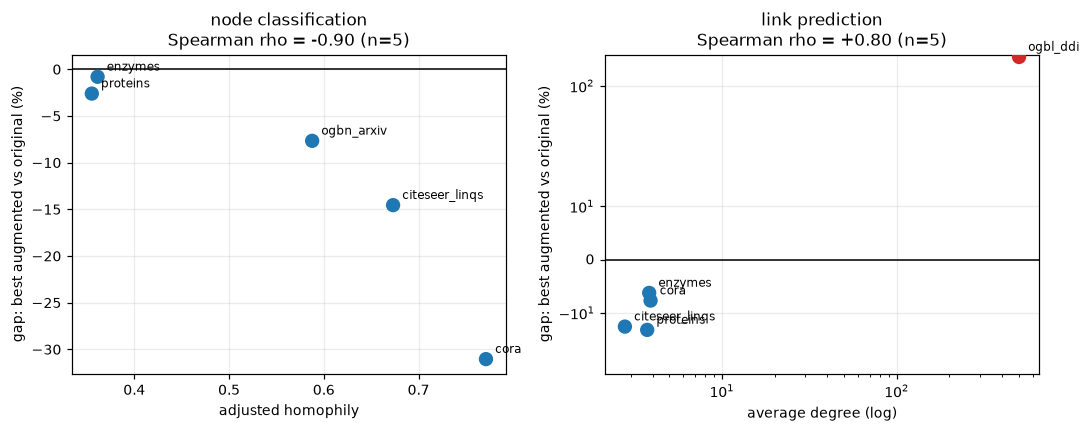

In [6]:
"""The gap against its best predictor, one panel per task - the headline of the study."""
J = gap.merge(props, on="dataset")
PANELS = [("node classification", "homophily_adjusted", "adjusted homophily", False, False),
          ("link prediction", "avg_degree", "average degree (log)", True, True)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (task, prop, label, logx, symlog) in zip(axes, PANELS):
    g = J[J["task_family"] == task].dropna(subset=[prop])
    r = corr[(corr["task_family"] == task) & (corr["predictor"] == prop)].iloc[0]
    ax.axhline(0, color="k", lw=1)
    ax.scatter(g[prop], 100 * g["gap_rel"], s=70, c=["tab:red" if v > 0 else "tab:blue" for v in g["gap_rel"]], zorder=3)
    for _, row in g.iterrows():
        ax.annotate(row["dataset"], (row[prop], 100 * row["gap_rel"]), textcoords="offset points",
                    xytext=(6, 4), fontsize=8)
    if logx:
        ax.set_xscale("log")
    if symlog:
        ax.set_yscale("symlog", linthresh=20)      # ddi's +200% is a floor effect (original = 0.017), so compress it
    ax.set(xlabel=label, ylabel="gap: best augmented vs original (%)",
           title=f"{task}\nSpearman rho = {r.spearman_rho:+.2f} (n={r.n})")
show(fig, "fig2_gap_vs_predictor")

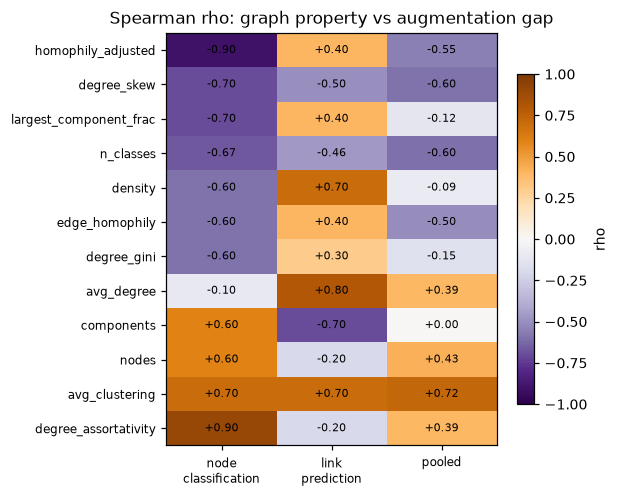

In [7]:
"""Every property against the gap, both tasks - the evidence behind the two panels above."""
H = (corr[corr["scope"].str.startswith("graph")]
     .pivot(index="predictor", columns="task_family", values="spearman_rho")
     .reindex(PREDICTORS)[["node classification", "link prediction", "pooled"]])
H = H.sort_values("node classification")

fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.imshow(H.values, cmap="PuOr_r", vmin=-1, vmax=1, aspect="auto")
ax.grid(False)
ax.set_xticks(range(H.shape[1]), [c.replace(" ", "\n") for c in H.columns], fontsize=8)
ax.set_yticks(range(len(H)), H.index, fontsize=8)
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        ax.text(j, i, f"{H.values[i, j]:+.2f}", ha="center", va="center", fontsize=7.5)
ax.set_title("Spearman rho: graph property vs augmentation gap")
fig.colorbar(im, ax=ax, label="rho", shrink=0.8)
show(fig, "fig3_property_correlations")

## 6 · Which node feature helps?

GraphSAGE is fed four structural features (degree, eigenvector centrality, Ψ, clustering). Ablation D switches them on one at a time — `psi` graph, K = 10, **core four only**; the OGB pair has no ablation arms.

- Bars = **lift over the random-feature control**: message passing with the structural signal removed. Positive means the feature earns its place.
- **clustering** is the molecular workhorse; **centrality** wins the citation graphs and molecular link prediction.
- Second figure: a feature's raw spread does **not** predict its usefulness (|ρ| ≤ 0.06). The molecular winners are exactly the features a "too few distinct values" heuristic would discard, so **usefulness is decided by ablation score, never by the `degenerate` flag**.
- Only unit-free statistics are plotted; `raw_std` carries each feature's own units and is not comparable across features.

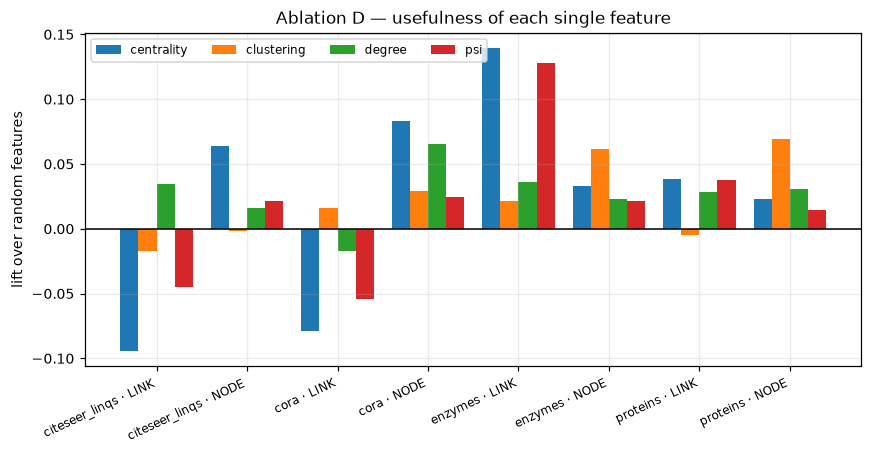

In [8]:
"""Ablation D lift over the random-feature control, per dataset x task."""
S = ablation[ablation["feature"].notna()].copy()
S["cell"] = S["dataset"] + " · " + S["task_family"].str.split(" ").str[0].str.upper()
L = S.pivot(index="cell", columns="arm", values="lift_vs_random").sort_index()

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(L))
for i, arm in enumerate(L.columns):
    ax.bar(x + (i - 1.5) * 0.2, L[arm], width=0.2, label=arm)
ax.axhline(0, color="k", lw=1)
ax.set_xticks(x, L.index, rotation=25, ha="right", fontsize=8)
ax.set(ylabel="lift over random features", title="Ablation D — usefulness of each single feature")
ax.legend(fontsize=8, ncol=4, loc="upper left")
show(fig, "fig4_feature_lift")

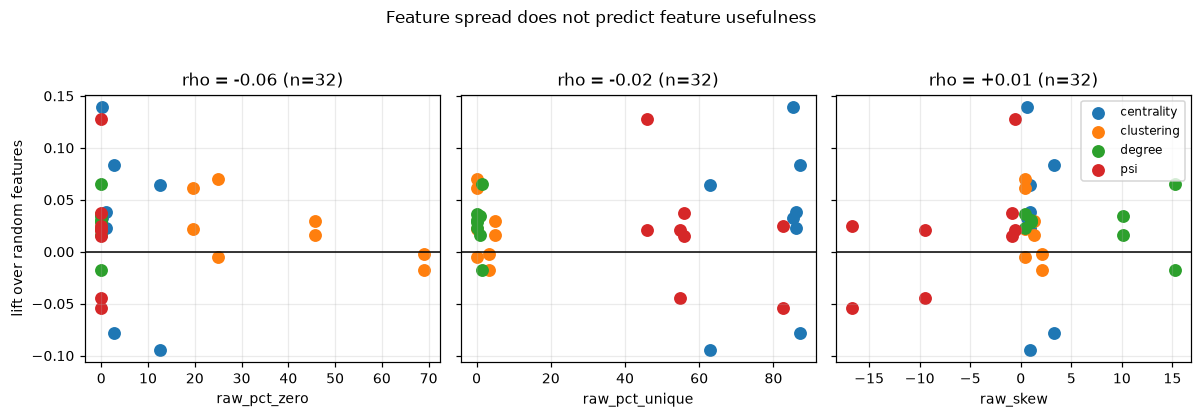

In [9]:
"""Raw distribution statistics against measured usefulness - the test the degenerate flag would have to pass."""
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
for ax, p in zip(axes, ["raw_pct_zero", "raw_pct_unique", "raw_skew"]):
    r = corr[(corr["scope"].str.startswith("feature")) & (corr["task_family"] == "pooled")
             & (corr["predictor"] == p)].iloc[0]
    for arm, g in S.groupby("arm"):
        ax.scatter(g[p], g["lift_vs_random"], s=55, label=arm)
    ax.axhline(0, color="k", lw=1)
    ax.set(xlabel=p, title=f"rho = {r.spearman_rho:+.2f} (n={r.n})")
axes[0].set_ylabel("lift over random features")
axes[-1].legend(fontsize=8)
fig.suptitle("Feature spread does not predict feature usefulness", y=1.04)
show(fig, "fig5_spread_vs_usefulness")

## 7 · Final recommendation

One row per dataset × task: the answer, the graph to use, the feature that earns its place, and the evidence.

- `use_graph` — `original` when the verdict is *keep original* or *tie* (the original is the cheaper default); the best augmented variant when the verdict is *augment*.
- `useful_feature` — the best single-feature ablation arm and its lift over random features. **`not measured`** for `ogbn_arxiv` / `ogbl_ddi`: ablation D was run on the core four only.
- `evidence` — the gap in the cell's own metric, in units of pooled 3-seed noise, plus where the original graph ranks among the five.

In [10]:
"""The when-to-augment answer per cell, with the feature ablation and the evidence beside it."""
best = S.loc[S.groupby(["dataset", "task_family"])["mean"].idxmax()]        # strongest single feature in that cell
rec = gap.merge(best[["dataset", "task_family", "arm", "lift_vs_random"]], on=["dataset", "task_family"], how="left")
rec["use_graph"] = np.where(rec["verdict"] == "augment", rec["best_variant"], "original")
rec["useful_feature"] = [f"{a} ({l:+.3f})" if a == a else "not measured" for a, l in zip(rec["arm"], rec["lift_vs_random"])]
rec["evidence"] = [f"{r.gap_abs:+.4f} {r.metric} = {r.gap_sigma:+.1f} sigma | original ranks {r.original_rank}/5"
                   for r in rec.itertuples()]

rec[["dataset", "task_family", "verdict", "use_graph", "best_variant", "useful_feature", "evidence"]]

,dataset,task_family,verdict,use_graph,best_variant,useful_feature,evidence
0,citeseer_linqs,link prediction,keep original,original,centrality,degree (+0.035),-0.0781 auc = -3.6 sigma | original ranks 1/5
1,cora,link prediction,keep original,original,centrality,clustering (+0.016),-0.0471 auc = -11.5 sigma | original ranks 1/5
2,enzymes,link prediction,keep original,original,centrality,centrality (+0.140),-0.0437 auc = -6.1 sigma | original ranks 1/5
3,ogbl_ddi,link prediction,augment,centrality,centrality,not measured,+0.0346 test_hits@20 = +2.7 sigma | original r...
4,proteins,link prediction,keep original,original,centrality,centrality (+0.039),-0.0886 auc = -23.3 sigma | original ranks 1/5
5,citeseer_linqs,node classification,keep original,original,centrality,centrality (+0.064),-0.0480 weighted_f1 = -3.8 sigma | original ra...
6,cora,node classification,keep original,original,centrality,centrality (+0.083),-0.1324 weighted_f1 = -8.6 sigma | original ra...
7,enzymes,node classification,tie,original,hybrid,clustering (+0.061),-0.0045 weighted_f1 = -0.7 sigma | original ra...
8,ogbn_arxiv,node classification,keep original,original,hybrid,not measured,-0.0300 test_acc = -6.2 sigma | original ranks...
9,proteins,node classification,keep original,original,hybrid,clustering (+0.070),-0.0151 weighted_f1 = -8.9 sigma | original ra...


In [11]:
"""The same reading printed by `characterize.py --step all`, for the record."""
rule(gap, corr, ablation)


VERDICT PER CELL (1 sigma band on the 3-seed noise)
       dataset         task_family       metric  original  best_augmented best_variant  gap_abs  gap_sigma  original_rank       verdict
citeseer_linqs     link prediction          auc    0.6218          0.5437   centrality  -0.0781      -3.64              1 keep original
          cora     link prediction          auc    0.6130          0.5659   centrality  -0.0471     -11.54              1 keep original
       enzymes     link prediction          auc    0.7000          0.6563   centrality  -0.0437      -6.09              1 keep original
      ogbl_ddi     link prediction test_hits@20    0.0173          0.0519   centrality   0.0346       2.70              5       augment
      proteins     link prediction          auc    0.6720          0.5834   centrality  -0.0886     -23.28              1 keep original
citeseer_linqs node classification  weighted_f1    0.3298          0.2818   centrality  -0.0480      -3.79              1 keep orig